## EDA dan Rekayasa Fitur Dataset Google Play Store

1. Pernyataan Masalah. Saat ini, terdapat 1,85 juta aplikasi berbeda yang tersedia untuk diunduh pengguna. Pengguna Android memiliki lebih banyak pilihan, dengan 2,56 juta aplikasi tersedia melalui Google Play Store. Aplikasi-aplikasi ini telah memainkan peran besar dalam cara kita menjalani hidup saat ini. Tujuan kami adalah menemukan Kategori Paling Populer, menemukan Aplikasi dengan jumlah penginstalan terbanyak, Aplikasi dengan ukuran terbesar, dll.
2. Pengumpulan Data.

Langkah langkah yg akan kita lakukan 

1. pembersihan data
2. melakukan EDA 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

LOAD DATASET langsung tanpa di download dlu

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
# cek dimensi 
df.shape

(10841, 13)

In [4]:
# cek ada tipe dat apa aja 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [5]:
# statistik deskriptif
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [6]:
# cek missing value 
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

wawasan :
ada dataset yg kosong/hilang

In [7]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [8]:
# lihat uniqe review
df['Reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'],
      shape=(6002,), dtype=object)

In [9]:
# hitung berapa nilai valid di reviews yg numeric
df['Reviews'].str.isnumeric().sum()

np.int64(10840)

In [10]:
# filter baris yg bukan numeric di reviews
df[~df['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [11]:
# bikin copy  dataset agar yg asli aman
df_copy = df.copy()

In [12]:
# hapus baris ke 10472 karena memiliki nilai invalid di reviews
df_copy = df_copy.drop(10472, axis=0)

In [13]:
# verifikasi pakah berhasil
df_copy['Reviews']= df_copy['Reviews'].astype(int)

In [14]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.2+ MB


In [15]:
# cek niai uniqe di size
df_copy['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

Bersihin Size: replace 'M' jadi '000', hilangin 'k', NaN-in 'Varies with device', convert ke float.

In [16]:
# Ganti nama kolom jadi 'Size' (S besar) dan perbaiki 'K' jadi 'k' kecil
df_copy['Size'] = df_copy['Size'].str.replace('M', '000')
df_copy['Size'] = df_copy['Size'].str.replace('k', '')

# SULAP TEKS JADI KOSONG: 'Varies with device' diubah jadi NaN biar bisa dihitung matematika
df_copy['Size'] = df_copy['Size'].replace('Varies with device', np.nan)

# Paksa kolom jadi angka desimal (float)
df_copy['Size'] = df_copy['Size'].astype(float)

In [17]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 1.2+ MB


Cek unique Installs — ada simbol '+' dan ','.

In [18]:
# cek unique instaalls
df_copy['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

Cek unique Price — ada simbol '$'.

In [19]:
# cek unique price
df_copy['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

Loop bersih-bersih: hapus '+', ',', '$' dari kolom Installs & Price sekaligus.

In [20]:
chars_to_remove=['+',',','$']
cols_to_clean=['Installs','Price']
for item in chars_to_remove:
    for cols in cols_to_clean:
        df_copy[cols]=df_copy[cols].str.replace(item,'')

In [21]:
# verifikasi  price 
df_copy['Price'].unique()

array(['0', '4.99', '3.99', '6.99', '1.49', '2.99', '7.99', '5.99',
       '3.49', '1.99', '9.99', '7.49', '0.99', '9.00', '5.49', '10.00',
       '24.99', '11.99', '79.99', '16.99', '14.99', '1.00', '29.99',
       '12.99', '2.49', '10.99', '1.50', '19.99', '15.99', '33.99',
       '74.99', '39.99', '3.95', '4.49', '1.70', '8.99', '2.00', '3.88',
       '25.99', '399.99', '17.99', '400.00', '3.02', '1.76', '4.84',
       '4.77', '1.61', '2.50', '1.59', '6.49', '1.29', '5.00', '13.99',
       '299.99', '379.99', '37.99', '18.99', '389.99', '19.90', '8.49',
       '1.75', '14.00', '4.85', '46.99', '109.99', '154.99', '3.08',
       '2.59', '4.80', '1.96', '19.40', '3.90', '4.59', '15.46', '3.04',
       '4.29', '2.60', '3.28', '4.60', '28.99', '2.95', '2.90', '1.97',
       '200.00', '89.99', '2.56', '30.99', '3.61', '394.99', '1.26',
       '1.20', '1.04'], dtype=object)

In [22]:
# verifikasi installs
df_copy['Installs'].unique()

array(['10000', '500000', '5000000', '50000000', '100000', '50000',
       '1000000', '10000000', '5000', '100000000', '1000000000', '1000',
       '500000000', '50', '100', '500', '10', '1', '5', '0'], dtype=object)

Convert ke tipe data yang bener: Installs jadi int, Price jadi float.

In [23]:
df_copy['Installs']= df_copy['Installs'].astype('int')
df_copy['Price']= df_copy['Price'].astype('float')

In [24]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 1.2+ MB


Datetime engineering: parse Last Updated jadi datetime, lalu extract Day/Month/Year.

In [25]:
df_copy['Last Updated'] = pd.to_datetime(df_copy['Last Updated'])
df_copy['Day'] = df_copy['Last Updated'].dt.day
df_copy['Month'] = df_copy['Last Updated'].dt.month
df_copy['Year'] = df_copy['Last Updated'].dt.year

In [26]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  object        
 1   Category        10840 non-null  object        
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  int64         
 4   Size            9145 non-null   float64       
 5   Installs        10840 non-null  int64         
 6   Type            10839 non-null  object        
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10840 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10832 non-null  object        
 12  Android Ver     10838 non-null  object        
 13  Day             10840 non-null  int32         
 14  Month           10840 non-null  int32         
 15  Year   

Value counts Content Rating — distribusi rating konten.

In [27]:
df_copy['Content Rating'].value_counts()

Content Rating
Everyone           8714
Teen               1208
Mature 17+          499
Everyone 10+        414
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

## EDA 

In [28]:
# Cek duplikat berdasarkan kolom App.
df_copy[df_copy.duplicated(['App'])].shape

(1181, 16)

### Pengamatan
dataset memiliki rekaman duplikat

Drop duplicates — keep yg pertama aja.

In [29]:
df_copy = df_copy.drop_duplicates(subset=['App'],keep='first')

In [30]:
# verifikasi udh gaada duplicate
df_copy[df_copy.duplicated(['App'])].shape

(0, 16)

pisahin numerin dan kategorikal nya 

In [31]:
numerical_features = [feature for feature in df_copy.columns if df_copy[feature].dtype != 'O']
kategorikal_features = [feature for feature in df_copy.columns if df_copy[feature].dtype == 'O']

# cetak kolom-kolom
print('We have {} numerical features : {}'.format(len(numerical_features), numerical_features))
print('\nWe have {} kategorikal features : {}'.format(len(kategorikal_features),kategorikal_features))

We have 9 numerical features : ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Last Updated', 'Day', 'Month', 'Year']

We have 7 kategorikal features : ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


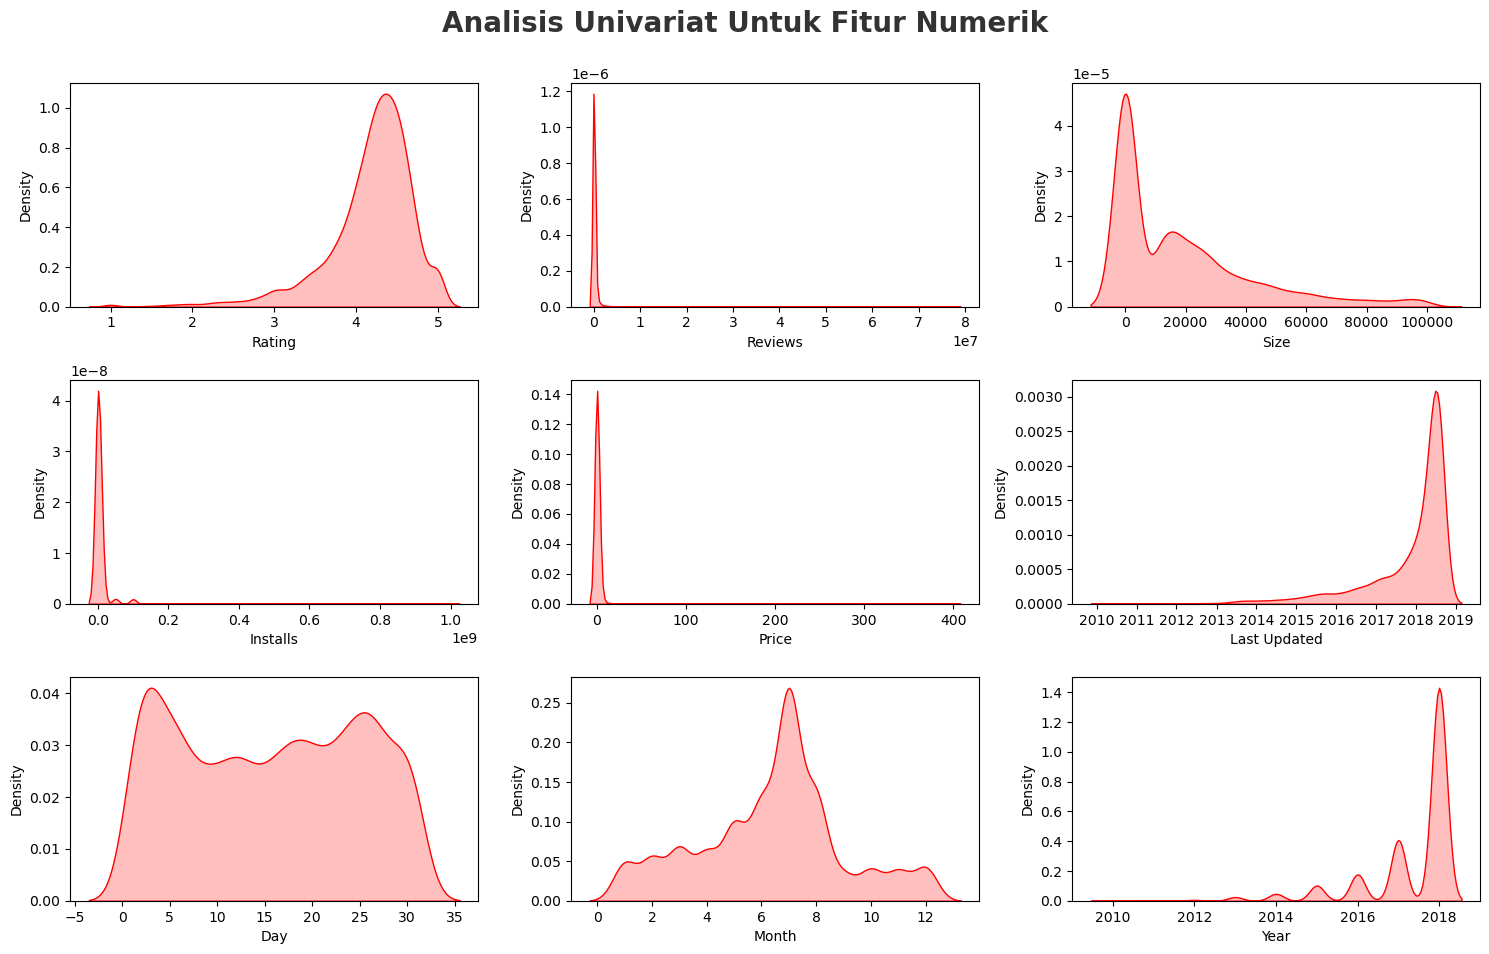

In [32]:
## Diagram visualisasi

plt.figure(figsize=(15, 15))
plt.suptitle('Analisis Univariat Untuk Fitur Numerik', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numerical_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df_copy[numerical_features[i]],shade=True, color='r')
    plt.xlabel(numerical_features[i])
    plt.tight_layout()

Observasi
- Rating dan Tahun hampir disebutkan sebagai data yang berkecil sedangkan Reviews, Ukuran, Installs dan Harga hampaknya disebutkan sebagai data yang besar.

Count plot kategorikal: Type (Free/Paid) & Content Rating.

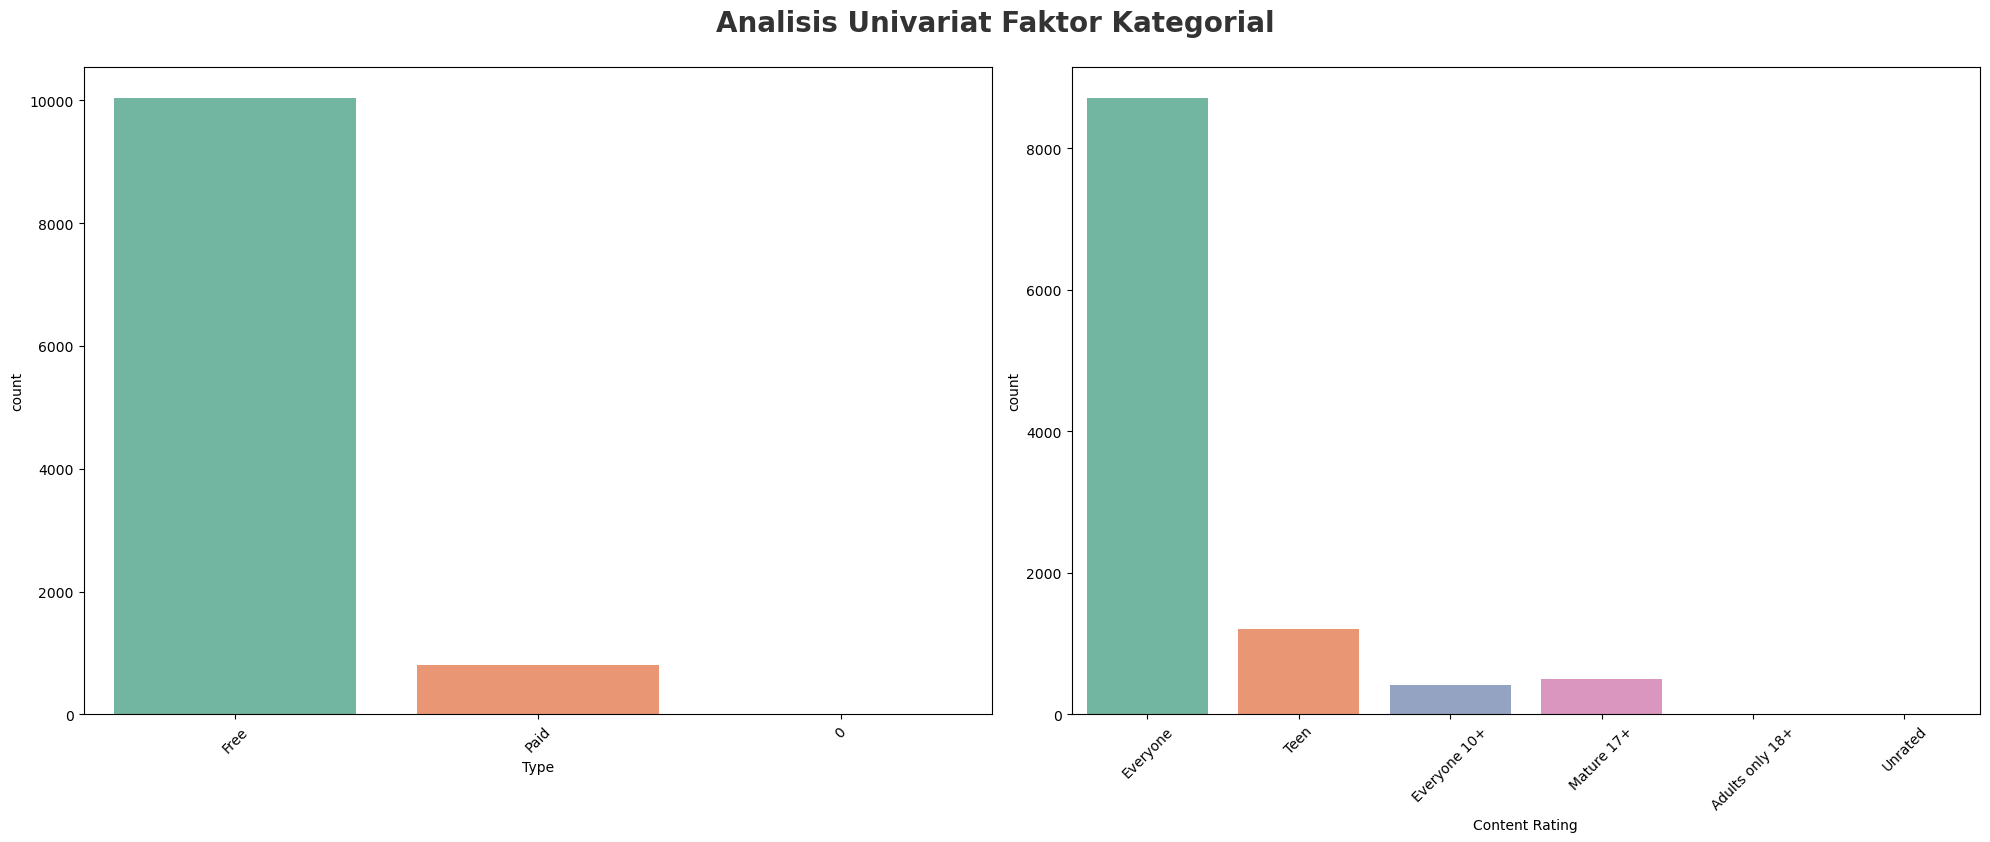

In [33]:
# Kolom kategorial
plt.figure(figsize=(20, 15))
plt.suptitle('Analisis Univariat Faktor Kategorial', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
category = [ 'Type', 'Content Rating']
for i in range(0, len(category)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=df[category[i]],palette="Set2")
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

yang adalah kategori aplikasi yang paling populer?
- Blok yang diindentasi

In [34]:
# Quick Check
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


Pie chart distribusi Category — proporsi kategori aplikasi di playstore.

<Axes: ylabel='count'>

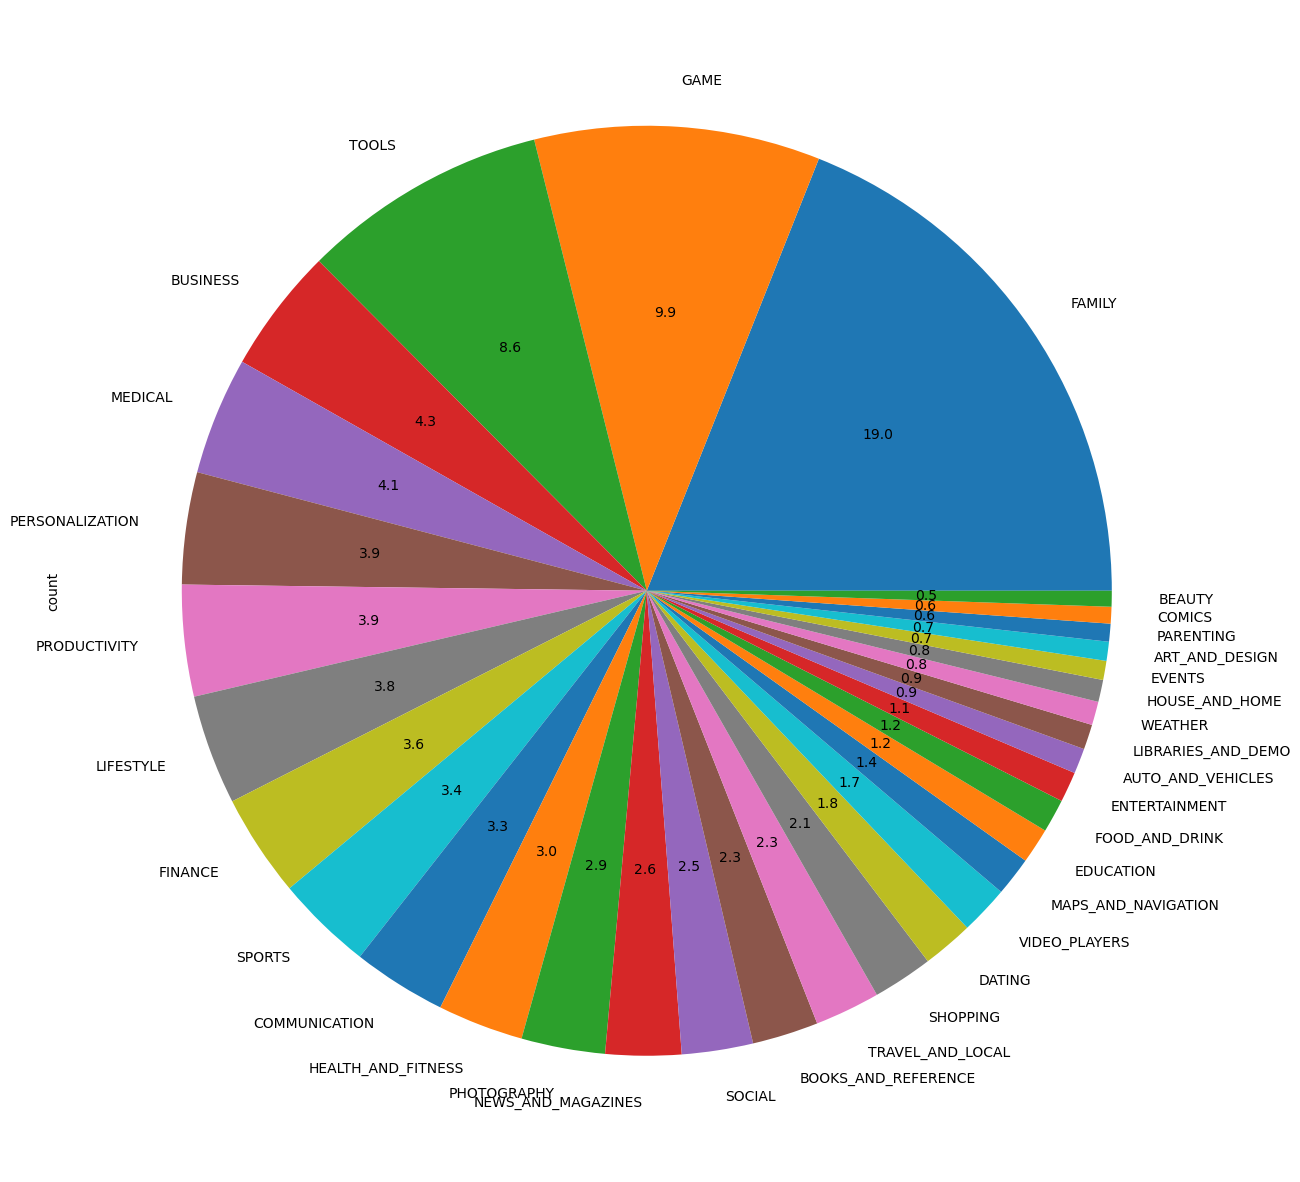

In [35]:
df_copy['Category'].value_counts().plot.pie(y = df_copy['Category'], figsize=(15,16),autopct='%1.1f')

## Pengamatan
1. Ada lebih banyak jenis aplikasi di Playstore yang berada dalam kategori keluarga, permainan, dan alat
2. Kategori aplikasi kecantikan, komik, seni, dan cuaca memiliki jumlah yang sangat sedikit di Playstore

In [36]:
## 10 Kategori Aplikasi Teratas

# DataFrame berdasarkan jumlah aplikasi pada kategori tertentu
category = pd.DataFrame(df_copy['Category'].value_counts())
category.rename(columns = {'Category':'Count'},inplace=True)
print(category)

                     count
Category                  
FAMILY                1832
GAME                   959
TOOLS                  827
BUSINESS               420
MEDICAL                395
PERSONALIZATION        376
PRODUCTIVITY           374
LIFESTYLE              369
FINANCE                345
SPORTS                 325
COMMUNICATION          315
HEALTH_AND_FITNESS     288
PHOTOGRAPHY            281
NEWS_AND_MAGAZINES     254
SOCIAL                 239
BOOKS_AND_REFERENCE    222
TRAVEL_AND_LOCAL       219
SHOPPING               202
DATING                 171
VIDEO_PLAYERS          163
MAPS_AND_NAVIGATION    131
EDUCATION              119
FOOD_AND_DRINK         112
ENTERTAINMENT          102
AUTO_AND_VEHICLES       85
LIBRARIES_AND_DEMO      84
WEATHER                 79
HOUSE_AND_HOME          74
EVENTS                  64
ART_AND_DESIGN          64
PARENTING               60
COMICS                  56
BEAUTY                  53


BAR PLOT 10 aplikasi teratas 

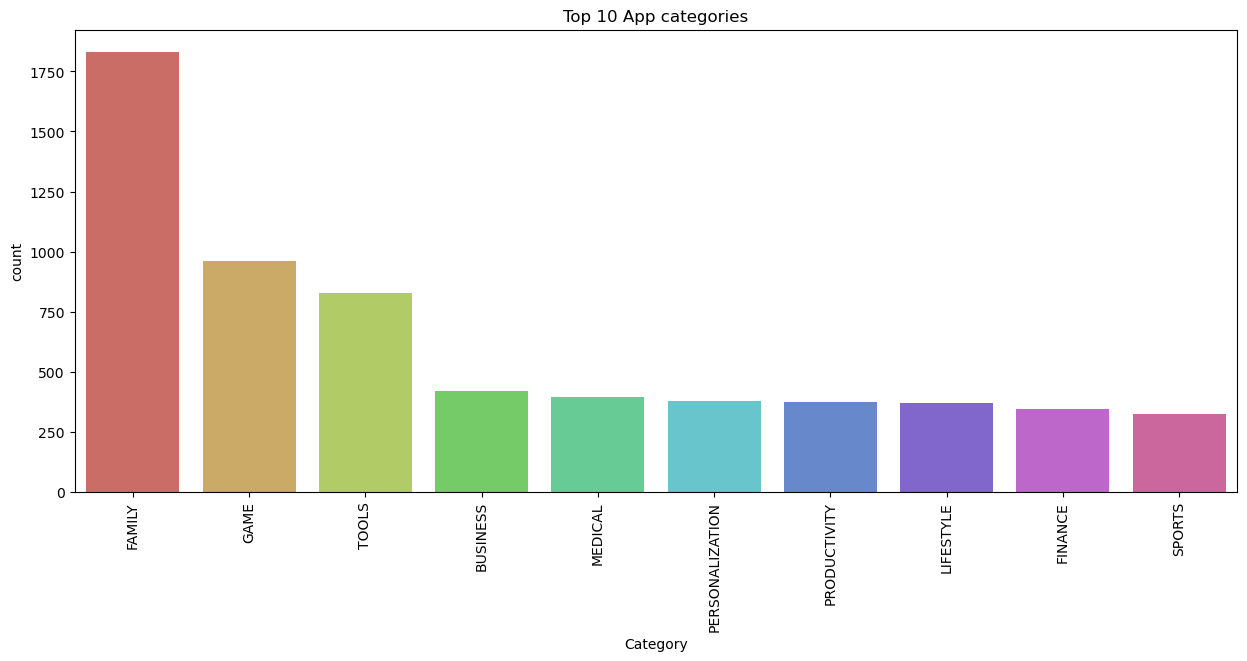

In [37]:
## 10 aplikasi teratas
plt.figure(figsize=(15,6))

# Mengambil nama kolom pertama dari DataFrame secara otomatis
nama_kolom_angka = category.columns[0]

# Gambar barplot menggunakan index dan nama kolom otomatis tadi
sns.barplot(
    x=category.index[:10], 
    y=category[nama_kolom_angka][:10], 
    palette='hls'
)

plt.title('Top 10 App categories')
plt.xticks(rotation=90)
plt.show()

In [38]:
# print 10 nama kategori teratas
category.index[:10]

Index(['FAMILY', 'GAME', 'TOOLS', 'BUSINESS', 'MEDICAL', 'PERSONALIZATION',
       'PRODUCTIVITY', 'LIFESTYLE', 'FINANCE', 'SPORTS'],
      dtype='object', name='Category')

Wawasan
1. Kategori Keluarga memiliki jumlah aplikasi terbanyak dengan 18% aplikasi, diikuti oleh kategori Permainan yang memiliki 11% aplikasi.
2. Jumlah aplikasi paling sedikit berada di kategori Kecantikan dengan kurang dari 1% dari total aplikasi.

In [39]:
# 1. Groupby berdasarkan Kategori, jumlahkan Installs, lalu urutkan dari terbesar
top_category_installs = df_copy.groupby('Category')['Installs'].sum().sort_values(ascending=False)

# 2. Tampilkan kategori nomor 1 teratas
print("Kategori dengan instalasi terbanyak adalah:")
print(top_category_installs.head())

Kategori dengan instalasi terbanyak adalah:
Category
GAME             13878924415
COMMUNICATION    11038276251
TOOLS             8001771915
PRODUCTIVITY      5793091369
SOCIAL            5487867902
Name: Installs, dtype: int64


5 Aplikasi yang paling banyak diinstal di setiap Kategori populer

In [40]:
# 1. Kita ambil dulu 3 kategori paling populer (terbanyak aplikasinya)
kategori_populer = df_copy['Category'].value_counts().head(3).index.tolist()

# 2. Filter data hanya untuk kategori populer tersebut
df_filtered = df_copy[df_copy['Category'].isin(kategori_populer)]

# 3. Ambil 5 aplikasi dengan 'Installs' terbesar di tiap kategori tersebut
top_5_apps_per_cat = df_filtered.groupby('Category').apply(lambda x: x.nlargest(5, 'Installs'))[['App', 'Installs']]

print("5 Aplikasi paling banyak diinstal di setiap Kategori populer:")
print(top_5_apps_per_cat)

5 Aplikasi paling banyak diinstal di setiap Kategori populer:
                                                   App    Installs
Category                                                          
FAMILY   3975                                  Hay Day   100000000
         4111                        Talking Tom Cat 2   100000000
         4217                           Talking Ginger   100000000
         4229                   Where's My Water? Free   100000000
         4247                          Talking Tom Cat   100000000
GAME     1654                           Subway Surfers  1000000000
         1655                         Candy Crush Saga   500000000
         1661                             Temple Run 2   500000000
         1662                                      Pou   500000000
         1722                           My Talking Tom   500000000
TOOLS    3234                                   Google  1000000000
         3235                         Google Translate   500000000


Berapa banyak aplikasi di Google Play Store yang mendapatkan 5 peringkat

In [41]:
# Filter baris yang Rating-nya pas 5.0, lalu hitung totalnya
jumlah_rating_5 = df_copy[df_copy['Rating'] == 5.0].shape[0]

print(f"Banyaknya aplikasi yang mendapatkan rating sempurna (5.0) adalah: {jumlah_rating_5} aplikasi")

Banyaknya aplikasi yang mendapatkan rating sempurna (5.0) adalah: 271 aplikasi
